# Zhang 2023 charging snippets

This notebook lists the released vehicles from the committed snippet index, loads every snippet of one vehicle, and plots one snippet. It makes no diagnosis.

## 1. Released units

This step lists what `systems('zhang2023')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('zhang2023')
display(released)

,unit,archive,car,label,snippets
0,battery_brand1:1,battery_brand1.tar.gz,1,0,2736
1,battery_brand1:2,battery_brand1.tar.gz,2,0,84
2,battery_brand1:3,battery_brand1.tar.gz,3,0,4319
3,battery_brand1:4,battery_brand1.tar.gz,4,0,597
4,battery_brand1:5,battery_brand1.tar.gz,5,0,1065
...,...,...,...,...,...
343,battery_brand3:496,battery_brand3.tar.gz,496,0,24
344,battery_brand3:497,battery_brand3.tar.gz,497,0,29
345,battery_brand3:498,battery_brand3.tar.gz,498,0,53
346,battery_brand3:499,battery_brand3.tar.gz,499,0,78


Each row is one labeled vehicle with its archive and snippet count. One labeled car, car 230 in battery_brand2, has no snippets, so the release carries data for 347 vehicles as the paper states.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
frame = load('zhang2023', unit='battery_brand3:401')
print(frame.shape)
display(frame.head())

(47616, 13)


,volt,current,soc,max_single_volt,min_single_volt,max_temp,min_temp,timestamp,snippet,label,charge_segment,mileage,unit
0,39.3652,-19.71,38.0,3.6821,3.6721,25.0,23.0,1281.0,1516,00,12,10602.77148,battery_brand3:401
1,39.3652,-19.79,38.0,3.6829,3.6729,25.0,23.0,1291.0,1516,00,12,10602.77148,battery_brand3:401
2,39.3652,-19.70,38.0,3.6821,3.6721,25.0,23.0,1301.0,1516,00,12,10602.77148,battery_brand3:401
3,39.3652,-19.70,38.0,3.6829,3.6730,25.0,23.0,1311.0,1516,00,12,10602.77148,battery_brand3:401
4,39.3652,-19.70,38.0,3.6821,3.6730,25.0,23.0,1321.0,1516,00,12,10602.77148,battery_brand3:401


Each snippet is 128 rows with its own relative clock in seconds, stacked with its charge segment, label and mileage.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['volt', 'current', 'soc', 'max_single_volt', 'min_single_volt', 'max_temp', 'mileage']].describe().T)

,count,mean,std,min,25%,50%,75%,max
volt,47616.0,42.774009,1.482168,38.34775,41.89990,42.97090,43.95860,45.12480
current,47616.0,-11.660661,5.740523,-20.10000,-18.10000,-7.00000,-6.80000,-6.01000
soc,47616.0,77.418280,16.076234,17.00000,69.00000,81.00000,90.00000,99.00000
max_single_volt,47616.0,4.006391,0.139467,3.58830,3.92600,4.02610,4.11610,4.22800
min_single_volt,47616.0,3.980927,0.137323,3.57720,3.89890,4.00090,4.09000,4.20200
max_temp,47616.0,22.428759,4.557343,11.00000,21.00000,23.00000,25.00000,30.00000
mileage,47616.0,10832.189392,361.655508,10137.58620,10544.80896,10892.68404,11161.21944,11323.71156


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

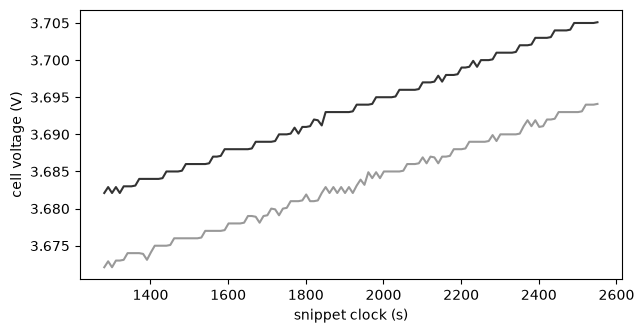

In [4]:
first = frame[frame['snippet'] == frame['snippet'].iloc[0]]
ax = first.plot(x='timestamp', y=['max_single_volt', 'min_single_volt'], figsize=(7, 3.5), color=['0.2', '0.6'], legend=False)
ax.set_xlabel('snippet clock (s)')
ax.set_ylabel('cell voltage (V)')
plt.show()

Within one snippet the two cell-voltage extremes rise together through the charge, about 10 mV apart.